# Load Data

In [45]:
# ============================================================
# STEP 0: Imports & Load Data
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats.contingency import association

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVC
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42

DATA_DIR = Path(".\\heart+disease")
FILE_NAMES = [
    "processed.cleveland.data", "processed.hungarian.data",
    "processed.switzerland.data", "processed.va.data",
]
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target",
]

frames = []
for file_name in FILE_NAMES:
    frame = pd.read_csv(DATA_DIR / file_name, header=None, names=FEATURE_NAMES, na_values="?")
    frame["source_file"] = file_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df[FEATURE_NAMES] = df[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
df["target_binary"] = (df["target"] > 0).astype(int)
df.drop(columns='target', inplace=True)
df.rename({'target_binary':'target'}, axis=1, inplace=True)

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.000,0.000,4.000,127.000,333.000,1.000,1.000,154.000,0.000,0.000,NaN,NaN,NaN,processed.va.data,1
916,62.000,1.000,1.000,NaN,139.000,0.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0
917,55.000,1.000,4.000,122.000,223.000,1.000,1.000,100.000,0.000,0.000,NaN,NaN,6.000,processed.va.data,1
918,58.000,1.000,4.000,NaN,385.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0


In [46]:
# change data type for categorical column
columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in columns:
    df[col] = df[col].astype('category')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.000,0.000,4.000,127.000,333.000,1.000,1.000,154.000,0.000,0.000,NaN,NaN,NaN,processed.va.data,1
916,62.000,1.000,1.000,NaN,139.000,0.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0
917,55.000,1.000,4.000,122.000,223.000,1.000,1.000,100.000,0.000,0.000,NaN,NaN,6.000,processed.va.data,1
918,58.000,1.000,4.000,NaN,385.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0


# EDA

In [47]:
# ============================================================
# STEP 1: EDA Awal (Statistics Descriptive, Cek Missing Value) --> Not related to feature selection, No risk of data leakage
# ============================================================

# 1. Ukuran data
print("1. JUMLAH OBSERVASI DAN FITUR")
print(f"Observasi: {len(df):,}")
print(f"Fitur asli: {len(FEATURE_NAMES) - 1:,} | Target: 1 | Kolom metadata: source_file, target")

1. JUMLAH OBSERVASI DAN FITUR
Observasi: 920
Fitur asli: 13 | Target: 1 | Kolom metadata: source_file, target


In [48]:
# 2. Data Type tiap Fitur
print("\n2. TIPE SETIAP FITUR")
type_table = pd.DataFrame({
    "feature": df[FEATURE_NAMES].columns,
    "dtype": df[FEATURE_NAMES].dtypes.astype(str).values,
    "n_unique": df[FEATURE_NAMES].nunique(dropna=True).values,
})
display(type_table)


2. TIPE SETIAP FITUR


,feature,dtype,n_unique
0,age,float64,50
1,sex,category,2
2,cp,category,4
3,trestbps,float64,61
4,chol,float64,217
5,fbs,category,2
6,restecg,category,3
7,thalach,float64,119
8,exang,category,2
9,oldpeak,float64,53


3. DISTRIBUSI TARGET


,count,percentage
target,,
0,411,44.674
1,509,55.326


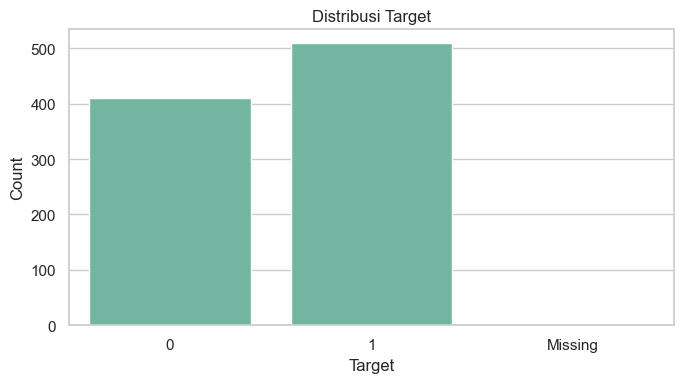

In [49]:
# 2. Distribusi Target
print("3. DISTRIBUSI TARGET")
target_distribution = pd.DataFrame({
    "count": df["target"].value_counts(dropna=False).sort_index(),
    "percentage": df["target"].value_counts(normalize=True, dropna=False).sort_index().mul(100),
})
display(target_distribution)

# tambahkan kategori "Missing" dulu sebelum fillna, karena dtype-nya category
target_plot = df["target"].cat.add_categories(["Missing"]).fillna("Missing")

plt.figure(figsize=(7, 4))
sns.countplot(
    x=target_plot,
    order=target_plot.value_counts().sort_index().index
)
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [50]:
# 4. Cek Missing Value
print("4. MISSING VALUES")
missing_table = pd.DataFrame({
    "missing_count": df[FEATURE_NAMES].isna().sum(),
    "missing_percentage": df[FEATURE_NAMES].isna().mean().mul(100),
}).sort_values("missing_count", ascending=False)
display(missing_table)

4. MISSING VALUES


,missing_count,missing_percentage
ca,611,66.413
thal,486,52.826
slope,309,33.587
fbs,90,9.783
oldpeak,62,6.739
trestbps,59,6.413
thalach,55,5.978
exang,55,5.978
chol,30,3.261
restecg,2,0.217


In [51]:
# 5. Cek Duplikat
print("5. DUPLICATE RECORDS")
print(f"Duplikat penuh (tanpa source_file): {df[FEATURE_NAMES].duplicated().sum():,}")
print(f"Duplikat identik antar semua kolom: {df.duplicated().sum():,}")

5. DUPLICATE RECORDS
Duplikat penuh (tanpa source_file): 2
Duplikat identik antar semua kolom: 2


6. DISTRIBUSI NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,920.000,53.511,9.425,28.000,47.000,54.000,60.000,77.000
trestbps,861.000,132.132,19.066,0.000,120.000,130.000,140.000,200.000
chol,890.000,199.130,110.781,0.000,175.000,223.000,268.000,603.000
thalach,865.000,137.546,25.926,60.000,120.000,140.000,157.000,202.000
oldpeak,858.000,0.879,1.091,-2.600,0.000,0.500,1.500,6.200


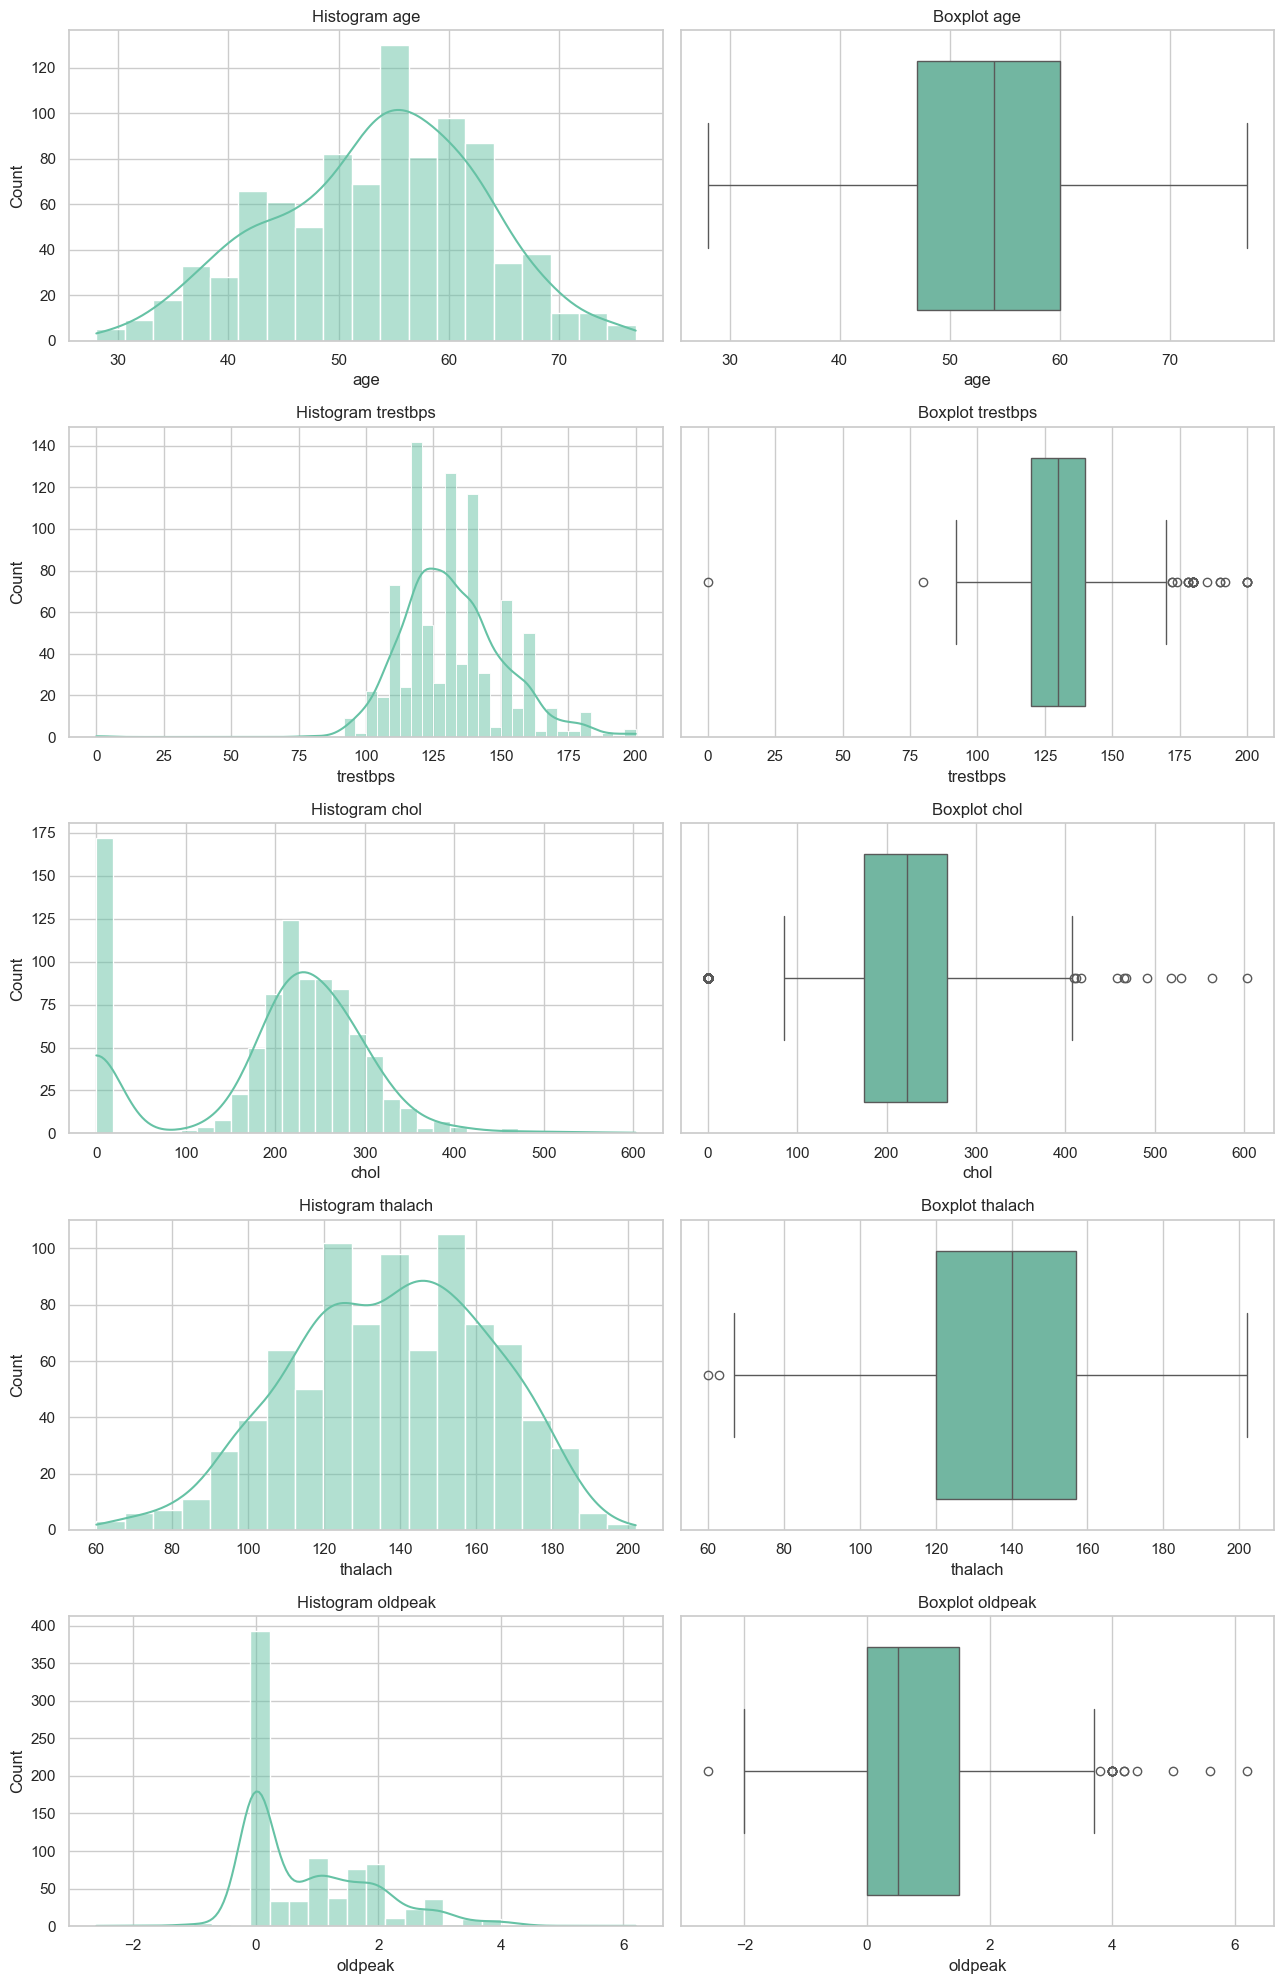

In [52]:
# 6. Distribusi fitur numerik
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("6. DISTRIBUSI NUMERICAL FEATURES")
display(df[numeric_features].describe().T)
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(13, 4 * len(numeric_features)))
for row, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[row, 0])
    axes[row, 0].set_title(f"Histogram {feature}")
    sns.boxplot(data=df, x=feature, ax=axes[row, 1])
    axes[row, 1].set_title(f"Boxplot {feature}")
plt.tight_layout()
plt.show()

7. DISTRIBUSI CATEGORICAL FEATURES

sex


,count,percentage
sex,,
1.000,726,78.913
0.000,194,21.087
Missing,0,0.000


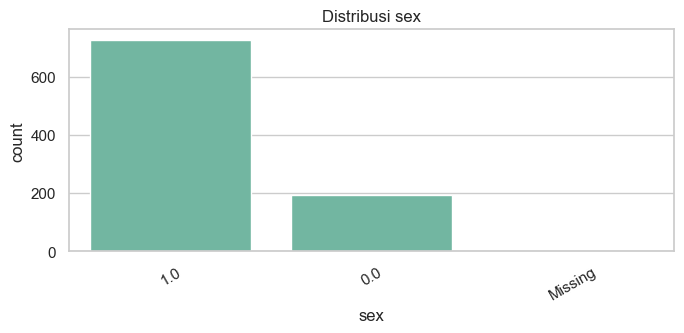


cp


,count,percentage
cp,,
4.000,496,53.913
3.000,204,22.174
2.000,174,18.913
1.000,46,5.000
Missing,0,0.000


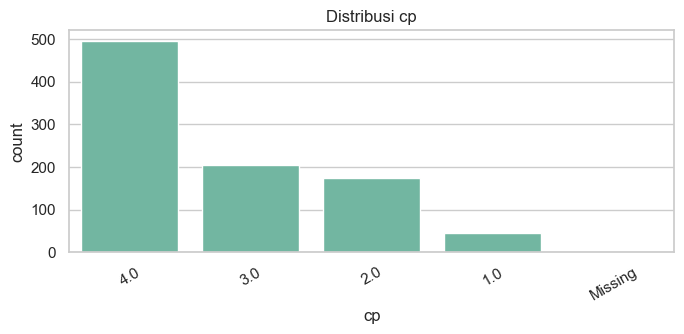


fbs


,count,percentage
fbs,,
0.000,692,75.217
1.000,138,15.000
Missing,90,9.783


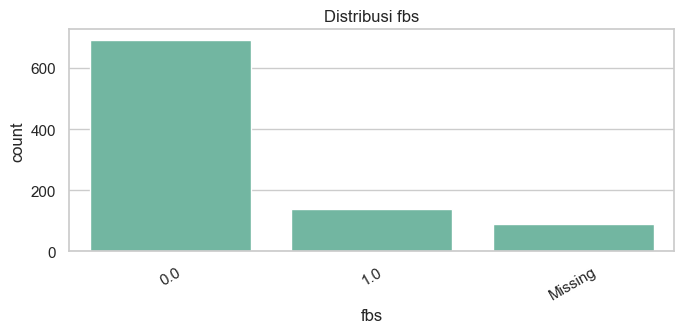


restecg


,count,percentage
restecg,,
0.000,551,59.891
2.000,188,20.435
1.000,179,19.457
Missing,2,0.217


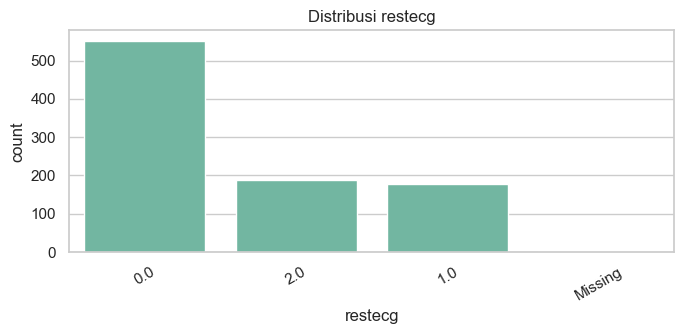


exang


,count,percentage
exang,,
0.000,528,57.391
1.000,337,36.630
Missing,55,5.978


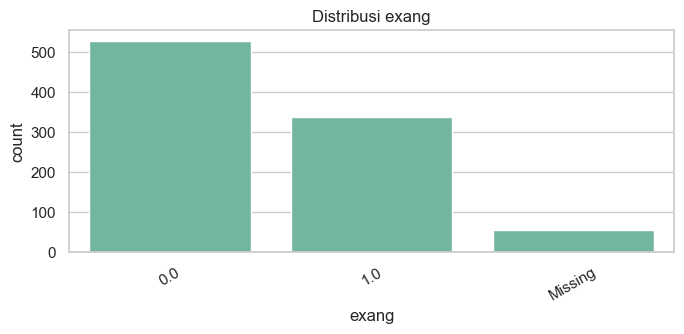


slope


,count,percentage
slope,,
2.000,345,37.500
Missing,309,33.587
1.000,203,22.065
3.000,63,6.848


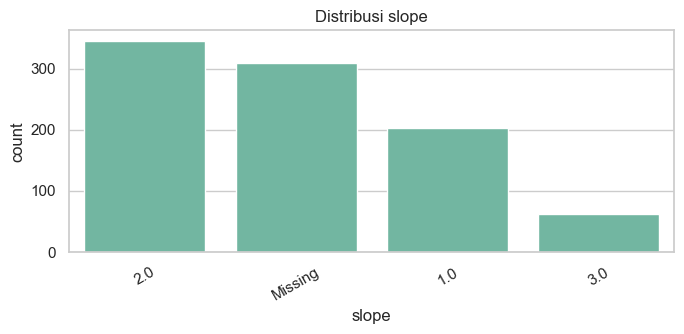


ca


,count,percentage
ca,,
Missing,611,66.413
0.000,181,19.674
1.000,67,7.283
2.000,41,4.457
3.000,20,2.174


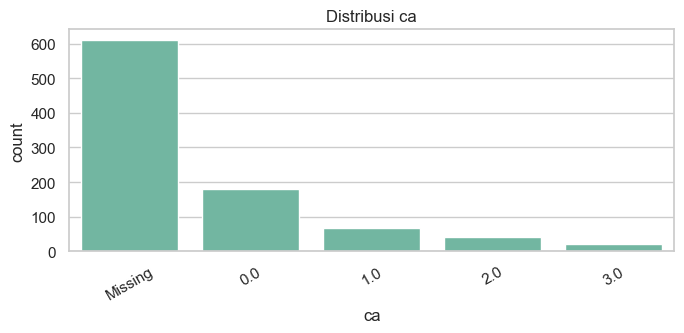


thal


,count,percentage
thal,,
Missing,486,52.826
3.000,196,21.304
7.000,192,20.870
6.000,46,5.000


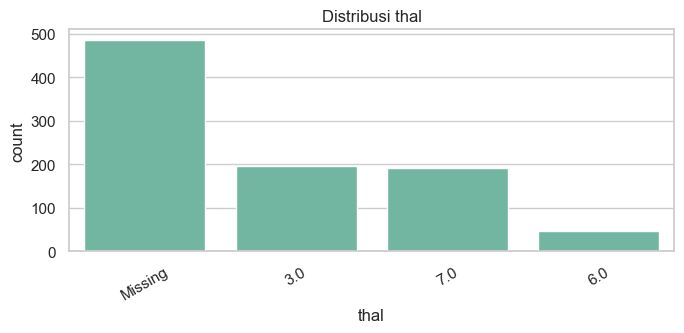

In [53]:
# 6. Distribusi fitur kategorik
print("7. DISTRIBUSI CATEGORICAL FEATURES")
for feature in categorical_features:
    series = df[feature]

    # tangani category dtype dan non-category dtype secara berbeda
    if isinstance(series.dtype, pd.CategoricalDtype):
        if "Missing" not in series.cat.categories:
            series = series.cat.add_categories(["Missing"])
        plot_series = series.fillna("Missing")
    else:
        plot_series = series.astype(str).fillna("Missing")

    distribution = plot_series.value_counts(dropna=False).rename_axis(feature).to_frame("count")
    distribution["percentage"] = distribution["count"].div(len(df)).mul(100)
    print(f"\n{feature}")
    display(distribution)

    plt.figure(figsize=(7, 3.5))
    sns.countplot(x=plot_series, order=plot_series.value_counts(dropna=False).index)
    plt.title(f"Distribusi {feature}")
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [54]:
# 8. Cek Anomali
print("8. ANOMALOUS VALUES (ATURAN DOMAIN)")
domain_rules = {
    "age": (0, 120),
    "sex": (0, 1),
    "cp": (1, 4),
    "trestbps": (50, 250),
    "chol": (50, 700),
    "fbs": (0, 1),
    "restecg": (0, 2),
    "thalach": (50, 250),
    "exang": (0, 1),
    "oldpeak": (-5, 10),
    "slope": (1, 3),
    "ca": (0, 3),
    "thal": (3, 7),
    "target": (0, 1),
}
anomaly_rows = []
for feature, (lower, upper) in domain_rules.items():
    # cast ke numerik untuk perbandingan, aman untuk category dtype maupun dtype lain
    values = pd.to_numeric(df[feature], errors="coerce")
    mask = values.notna() & ~values.between(lower, upper)
    anomaly_rows.append({
        "feature": feature,
        "allowed_range": f"[{lower}, {upper}]",
        "anomaly_count": int(mask.sum()),
        "anomaly_percentage": mask.mean() * 100,
    })
anomaly_table = pd.DataFrame(anomaly_rows).sort_values("anomaly_count", ascending=False)
display(anomaly_table)
print("Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.")

8. ANOMALOUS VALUES (ATURAN DOMAIN)


,feature,allowed_range,anomaly_count,anomaly_percentage
4,chol,"[50, 700]",172,18.696
3,trestbps,"[50, 250]",1,0.109
1,sex,"[0, 1]",0,0.000
0,age,"[0, 120]",0,0.000
2,cp,"[1, 4]",0,0.000
5,fbs,"[0, 1]",0,0.000
6,restecg,"[0, 2]",0,0.000
7,thalach,"[50, 250]",0,0.000
8,exang,"[0, 1]",0,0.000
9,oldpeak,"[-5, 10]",0,0.000


Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.


9. OUTLIER ANALYSIS (IQR)


,feature,q1,q3,lower_bound,upper_bound,outlier_count,outlier_percentage
2,chol,175.000,268.000,35.500,407.500,183,19.891
1,trestbps,120.000,140.000,90.000,170.000,28,3.043
4,oldpeak,0.000,1.500,-2.250,3.750,16,1.739
3,thalach,120.000,157.000,64.500,212.500,2,0.217
0,age,47.000,60.000,27.500,79.500,0,0.000


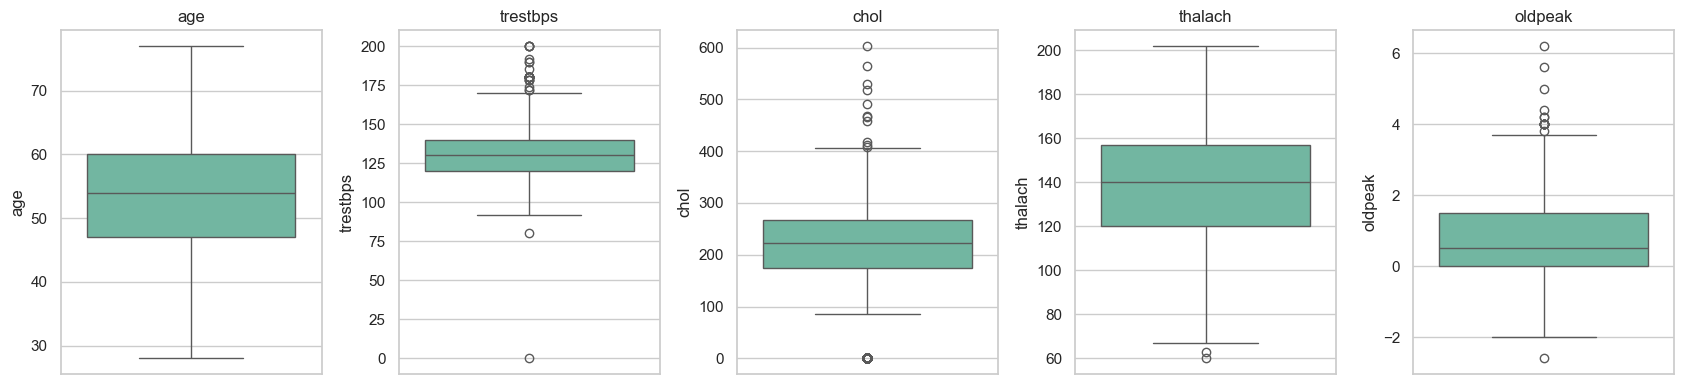

In [55]:
# 9. Cek Outlier
print("9. OUTLIER ANALYSIS (IQR)")
outlier_rows = []
for feature in numeric_features:
    values = df[feature].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = df[feature].notna() & ~df[feature].between(lower, upper)
    outlier_rows.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percentage": mask.mean() * 100,
    })
outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_table)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(17, 4))
for axis, feature in zip(axes, numeric_features):
    sns.boxplot(data=df, y=feature, ax=axis)
    axis.set_title(feature)
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# STEP 2: Tipe Fitur (cp direklasifikasi menjadi nominal;
# slope, ca, thal akan di-drop di awal karena missing rate ekstrem)
# ============================================================
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
binary_features = ["sex", "fbs", "exang"]
nominal_features = ["cp", "restecg"]
dropped_features = ["slope", "ca", "thal"]  # missing rate 33.6% / 66.4% / 52.8%

all_used_features = numeric_features + binary_features + nominal_features
all_used_features

['age',
 'trestbps',
 'chol',
 'thalach',
 'oldpeak',
 'sex',
 'fbs',
 'exang',
 'cp',
 'restecg']

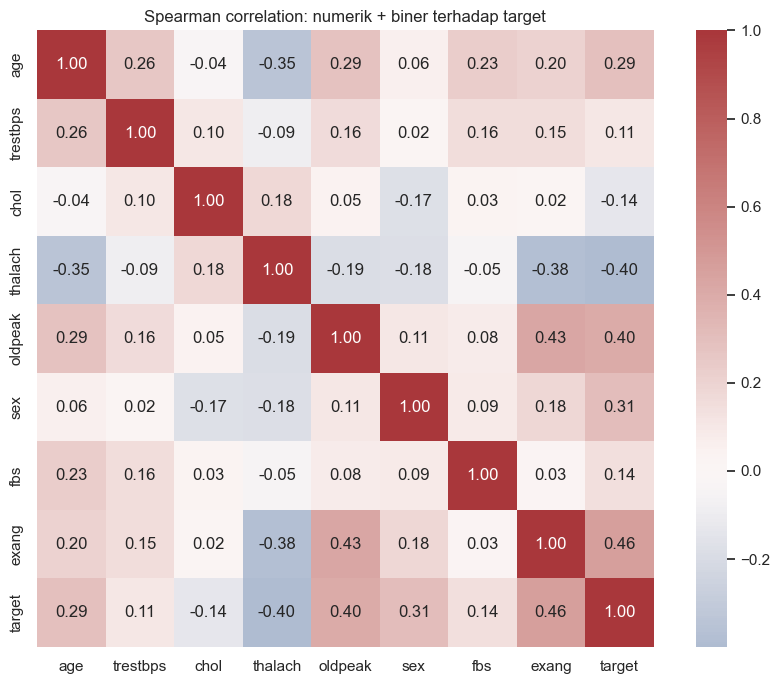


Cramér's V (fitur nominal vs target):


,feature,cramers_v
0,cp,0.540
1,restecg,0.113


In [57]:
# ============================================================
# STEP 3: Correlation Analysis
# (Spearman untuk numerik+biner; Cramér's V untuk nominal,
#  dihitung dari SELURUH df hanya untuk keperluan eksplorasi awal;
#  keputusan fitur final tetap berdasarkan domain knowledge di Step Selanjutnya)
# ============================================================
spearman_features = numeric_features + binary_features
spearman_corr = df[spearman_features + ["target"]].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlation: numerik + biner terhadap target")
plt.tight_layout()
plt.show()

print("\nCramér's V (fitur nominal vs target):")
cramers_rows = []
for feature in nominal_features:
    table = pd.crosstab(df[feature], df["target"])
    cramers_rows.append({"feature": feature, "cramers_v": association(table, method="cramer")})
display(pd.DataFrame(cramers_rows).sort_values("cramers_v", ascending=False))

# Drop Columns with Missing Rate Extreme

In [58]:
# ============================================================
# STEP 4: Recode Structural Zero & Drop Fitur Missing Ekstrem
# ============================================================
df["chol"] = df["chol"].replace(0, np.nan)
df["trestbps"] = df["trestbps"].replace(0, np.nan)
# oldpeak=0 TIDAK di-recode — nilai 0 valid secara klinis (no ST depression)

print(f"\nFitur dikecualikan (missing rate ekstrem): {dropped_features}")
print(f"Fitur ({len(all_used_features)}): {all_used_features}")


Fitur dikecualikan (missing rate ekstrem): ['slope', 'ca', 'thal']
Fitur (10): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp', 'restecg']


# Split Data

In [59]:
# ============================================================
# STEP 5: Outer Train/Test Split (70%, 30%)
# ============================================================
X = df[all_used_features].copy()
y = df["target"].copy()

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTraining pool: {X_train_pool.shape}, Test set: {X_test.shape}")


Training pool: (644, 10), Test set: (276, 10)


## K-Fold Cross Validation

In [60]:
# ============================================================
# STEP 6: Stratified K-Fold (K=5) — inner CV untuk tuning
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## Preprocessing

Mengikuti pembagian 4 kelompok berdasarkan kemiripan cara pengerjaan:

| Kelompok | Model | Preprocessing | Feature selection |
|---|---|---|---|
| 1 (Tree-based) | Decision Tree, Random Forest | Tanpa scaling (`preprocessor_tree`) | `SelectFromModel` (importance milik model sendiri) |
| 2 (Ensemble boosting & margin-based) | XGBoost, SVM | Dengan scaling untuk SVM (`preprocessor_svm`); tanpa scaling untuk XGBoost (`preprocessor_xgb`) | `SelectFromModel` (XGBoost: importance sendiri; SVM: linear SVM sebagai basis seleksi, model final tetap RBF) |
| 3 (Distance-based & probabilistic) | KNN, Naive Bayes | Dengan scaling (`preprocessor_scale_sensitive`) | `SelectKBest` (keduanya tidak punya feature importance bawaan,feature selection memakai `SelectKBest` (ANOVA F-test)|
| 4 (Implementasi custom) | LVQ, RBF Network | Dengan scaling (`preprocessor_scale_sensitive`) | `SelectKBest` (idem — tidak ada importance bawaan) |

Seluruh model pada bagian ini memakai `X_train_pool`, `y_train_pool`, `X_test`,
`y_test`, dan `cv` (Stratified K-Fold, K=5) yang sama persis. <br>

**Kenapa scaling dibedakan** <br>
**SVM** : Menggunakan kernel RBF yang bekerja dengan jarak antar titik, jadi fitur berskala besar (misalnya chol sekitar 200) <br> akan mendominasi fitur berskala kecil (oldpeak sekitar 0-6), sehingga perlu standarisasi skalanya. <br>
**XGBoost, Decision Tree, Random Forest** : Model berbasis pohon yang hanya melihat urutan nilai (split berdasarkan threshold), sehingga scaling tidak memengaruhi hasil.<br>
**KNN, Naive Bayes, LVQ, RBF Network** : Berbasis jarak/asumsi distribusi, sama seperti SVM, semuanya butuh scaling agar fitur berskala besar tidak mendominasi.<br>
**LVQ** diimplementasikan dari nol (LVQ1) — paket eksternal `sklearn_lvq`
  incompatible dengan scipy versi modern (`ValueError: x0 must only have one
  dimension`), dan paper aslinya juga tidak mendefinisikan parameter LVQ
  secara lengkap.
**RBF Network** didekati dengan `RBFSampler` (aproksimasi kernel RBF,
  Random Kitchen Sinks) diikuti classifier linear (`LogisticRegression`).

**Missing Value Imputation** <br>
Seluruh kelompok memakai strategi imputasi yang **sama**, terlepas dari jenis modelnya — perbedaan antar kelompok cuma pada scaling dan feature selection, bukan pada cara mengisi missing value:<br>
- **Fitur numerik** (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) → **median** (`SimpleImputer(strategy="median")`), dipilih karena robust terhadap outlier — EDA menemukan distribusi skewed dan sejumlah outlier pada `chol`, `trestbps`, dan `oldpeak`.<br>
- **Fitur biner** (`sex`, `fbs`, `exang`) → **modus** (`SimpleImputer(strategy="most_frequent")`), karena mean tidak bermakna untuk data biner 0/1.<br>
- **Fitur nominal** (`cp`, `restecg`) → **modus**, diikuti `OneHotEncoder` — modus dipakai dengan alasan sama seperti fitur biner (mean/median tidak berlaku untuk data kategorikal), dan one-hot encoding baru diterapkan setelah imputasi supaya kategori yang hilang tidak ikut mendapat kolom dummy tersendiri.<br>
- `chol = 0` dan `trestbps = 0` sudah direcode menjadi `NaN` sebelum tahap ini (anomali klinis, bukan nilai valid), sehingga ikut diimputasi median seperti missing value lainnya. `oldpeak = 0` **tidak** direcode — nilai tersebut valid secara klinis (tidak ada ST depression).<br>
- `slope`, `ca`, `thal` **tidak diimputasi sama sekali** — dikecualikan dari seluruh 8 model karena missing rate ekstrem (33,6%–66,4%), keputusan yang diambil sebelum tahap ini (lihat bagian "Drop Columns with Missing Rate Extreme").<br>

**Other Preprocessing** <br>
*One-hot*: cp dan restecg diubah jadi kolom 0/1 per kategori karena angkanya hanya label, bukan urutan. <br> handle_unknown="ignore" mencegah error kalau ada kategori yang muncul di data test tapi tidak ada di train.<br>
*Output*: kira-kira 15 kolom (5 numerik + 3 biner + 7 hasil one-hot dari cp [4 kategori] dan restecg [3 kategori]), dengan nama seperti num__chol, bin__sex, nom__cp_3.0. Kolom ini yang kemudian disaring SelectFromModel/SelectKBest tergantung kelompoknya.<br>
Tidak ada kebocoran data: karena preprocessor ada di dalam Pipeline, median, modus, dan mean/std dihitung ulang dari data training tiap fold, <br>lalu diterapkan ke data validasi atau test — begitu juga feature selection (SelectFromModel/SelectKBest), yang ikut di-*fit* ulang per fold karena ditempatkan di dalam Pipeline yang sama.<br>
Kolom yang tidak terdaftar dibuang (remainder="drop" adalah default).

In [61]:
# ============================================================
# STEP 7: Preprocessing Pipelines
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif

numeric_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
numeric_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Preprocessing
preprocessor_tree = ColumnTransformer([
    ("num", numeric_pipeline_unscaled, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("nom", nominal_pipeline, nominal_features),
])

preprocessor_scale_sensitive = ColumnTransformer([
    ("num", numeric_pipeline_scaled, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("nom", nominal_pipeline, nominal_features),
])

preprocessor_svm = ColumnTransformer([
    ("num", numeric_pipeline_scaled, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("nom", nominal_pipeline, nominal_features),
])
preprocessor_xgb = ColumnTransformer([
    ("num", numeric_pipeline_unscaled, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("nom", nominal_pipeline, nominal_features),
])

## GridSearch Cross Validation

In [70]:
# ============================================================
# Pipeline + GridSearchCV — Random Forest
# ============================================================
rf_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("feature_selection", SelectFromModel(
        RandomForestClassifier(random_state=RANDOM_STATE),
        threshold="median"
    )),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
])

rf_param_grid = {
    "feature_selection__threshold": ["median", "mean"],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5, 10],
}

rf_search = GridSearchCV(
    rf_pipe, rf_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
rf_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")

rf_search.best_estimator_

Best params: {'feature_selection__threshold': 'median', 'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best CV accuracy: 0.8152


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [71]:
# ============================================================
# Pipeline + GridSearchCV — Decision Tree
# ============================================================
dt_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("feature_selection", SelectFromModel(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        threshold="median"
    )),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

dt_param_grid = {
    "feature_selection__threshold": ["median", "mean"],
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

dt_search = GridSearchCV(
    dt_pipe, dt_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
dt_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {dt_search.best_params_}")
print(f"Best CV accuracy: {dt_search.best_score_:.4f}")

dt_search.best_estimator_

Best params: {'feature_selection__threshold': 'mean', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best CV accuracy: 0.7687


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [72]:
# ============================================================
# Pipeline + GridSearchCV — KNN
# ============================================================
knn_pipe = Pipeline([
    ("preprocessor", preprocessor_scale_sensitive),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", KNeighborsClassifier()),
])

knn_param_grid = {
    "feature_selection__k": [5, 8, "all"],
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
}

knn_search = GridSearchCV(
    knn_pipe, knn_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
knn_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {knn_search.best_params_}")
print(f"Best CV accuracy: {knn_search.best_score_:.4f}")

knn_search.best_estimator_

Best params: {'feature_selection__k': 'all', 'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'uniform'}
Best CV accuracy: 0.7950


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [73]:
# ============================================================
# Pipeline + GridSearchCV — Naive Bayes (GaussianNB)
# Hanya punya satu hyperparameter berarti (var_smoothing); grid tetap
# dijalankan untuk konsistensi meskipun ruang pencariannya kecil.
# ============================================================
nb_pipe = Pipeline([
    ("preprocessor", preprocessor_scale_sensitive),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", GaussianNB()),
])

nb_param_grid = {
    "feature_selection__k": [5, 8, "all"],
    "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6],
}

nb_search = GridSearchCV(
    nb_pipe, nb_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
nb_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {nb_search.best_params_}")
print(f"Best CV accuracy: {nb_search.best_score_:.4f}")

nb_search.best_estimator_

Best params: {'feature_selection__k': 'all', 'model__var_smoothing': 1e-09}
Best CV accuracy: 0.7934


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [74]:
# ============================================================
# Implementasi custom: LVQ1 (Learning Vector Quantization)
# Ditulis dari nol karena scikit-learn tidak menyediakan LVQ secara native,
# dan sklearn_lvq (satu-satunya paket publik) incompatible dengan scipy
# versi modern. Parameter di bawah adalah pilihan yang wajar dan
# didokumentasikan, bukan hasil tuning untuk memaksimalkan akurasi —
# konsisten dengan fakta bahwa paper aslinya sendiri tidak mendefinisikan
# parameter LVQ (jumlah prototipe, skedul learning rate) secara lengkap.
# ============================================================
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels


class SimpleLVQClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, n_prototypes_per_class=3, learning_rate=0.1, n_epochs=50, random_state=42):
        self.n_prototypes_per_class = n_prototypes_per_class
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = unique_labels(y)
        rng = np.random.RandomState(self.random_state)

        prototypes, prototype_labels = [], []
        for cls in self.classes_:
            X_cls = X[y == cls]
            n_proto = min(self.n_prototypes_per_class, len(X_cls))
            idx = rng.choice(len(X_cls), size=n_proto, replace=False)
            prototypes.append(X_cls[idx])
            prototype_labels.extend([cls] * n_proto)
        prototypes = np.vstack(prototypes).astype(float)
        prototype_labels = np.array(prototype_labels)

        lr = self.learning_rate
        for epoch in range(self.n_epochs):
            for i in rng.permutation(len(X)):
                x_i, y_i = X[i], y[i]
                distances = np.linalg.norm(prototypes - x_i, axis=1)
                winner = np.argmin(distances)
                if prototype_labels[winner] == y_i:
                    prototypes[winner] += lr * (x_i - prototypes[winner])
                else:
                    prototypes[winner] -= lr * (x_i - prototypes[winner])
            lr = self.learning_rate * (1 - (epoch + 1) / self.n_epochs)

        self.prototypes_ = prototypes
        self.prototype_labels_ = prototype_labels
        return self

    def predict(self, X):
        check_is_fitted(self, ["prototypes_", "prototype_labels_"])
        X = check_array(X)
        return np.array([
            self.prototype_labels_[np.argmin(np.linalg.norm(self.prototypes_ - x_i, axis=1))]
            for x_i in X
        ])

    def predict_proba(self, X):
        check_is_fitted(self, ["prototypes_", "prototype_labels_"])
        X = check_array(X)
        proba = np.zeros((len(X), len(self.classes_)))
        for row, x_i in enumerate(X):
            distances = np.linalg.norm(self.prototypes_ - x_i, axis=1) + 1e-9
            weights = 1.0 / distances
            for cls_idx, cls in enumerate(self.classes_):
                mask = self.prototype_labels_ == cls
                proba[row, cls_idx] = weights[mask].sum()
            proba[row] /= proba[row].sum()
        return proba


In [75]:
# ============================================================
# Pipeline + GridSearchCV — LVQ (custom implementation)
# ============================================================
lvq_pipe = Pipeline([
    ("preprocessor", preprocessor_scale_sensitive),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", SimpleLVQClassifier(random_state=RANDOM_STATE)),
])

lvq_param_grid = {
    "feature_selection__k": [5, 8, "all"],
    "model__n_prototypes_per_class": [2, 3, 5],
    "model__learning_rate": [0.05, 0.1, 0.3],
    "model__n_epochs": [30, 50],
}

lvq_search = GridSearchCV(
    lvq_pipe, lvq_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
lvq_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {lvq_search.best_params_}")
print(f"Best CV accuracy: {lvq_search.best_score_:.4f}")

lvq_search.best_estimator_

Best params: {'feature_selection__k': 8, 'model__learning_rate': 0.3, 'model__n_epochs': 50, 'model__n_prototypes_per_class': 5}
Best CV accuracy: 0.7888


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [76]:
# ============================================================
# Pipeline + GridSearchCV — RBF Network (aproksimasi: RBFSampler + LogisticRegression)
# ============================================================
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression

rbf_pipe = Pipeline([
    ("preprocessor", preprocessor_scale_sensitive),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("rbf_features", RBFSampler(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

rbf_param_grid = {
    "feature_selection__k": [5, 8, "all"],
    "rbf_features__n_components": [50, 100, 200],
    "rbf_features__gamma": [0.1, 0.5, 1.0],
    "model__C": [0.1, 1, 10],
}

rbf_search = GridSearchCV(
    rbf_pipe, rbf_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
rbf_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {rbf_search.best_params_}")
print(f"Best CV accuracy: {rbf_search.best_score_:.4f}")

rbf_search.best_estimator_

Best params: {'feature_selection__k': 8, 'model__C': 10, 'rbf_features__gamma': 0.1, 'rbf_features__n_components': 200}
Best CV accuracy: 0.8028


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [77]:
# ============================================================
# Pipeline + GridSearchCV — XGBoost (feature selection via SelectFromModel)
# ============================================================
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("feature_selection", SelectFromModel(
        xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
        threshold="median"
    )),
    ("model", xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_STATE
    )),
])

xgb_param_grid = {
    "feature_selection__threshold": ["median", "mean"],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
}

xgb_search = GridSearchCV(
    xgb_pipe, xgb_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
xgb_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV accuracy: {xgb_search.best_score_:.4f}")

xgb_search.best_estimator_

Best params: {'feature_selection__threshold': 'median', 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV accuracy: 0.7718


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [78]:
# ============================================================
# STEP 9: Pipeline + GridSearchCV — SVM
# (feature selection via linear SVM, model final tetap RBF kernel)
# ============================================================
svm_pipe = Pipeline([
    ("preprocessor", preprocessor_svm),
    ("feature_selection", SelectFromModel(
        SVC(kernel="linear", random_state=RANDOM_STATE),
        threshold="median"
    )),
    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])

svm_param_grid = {
    "feature_selection__threshold": ["median", "mean"],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
}

svm_search = GridSearchCV(
    svm_pipe, svm_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
svm_search.fit(X_train_pool, y_train_pool)

print(f"Best params: {svm_search.best_params_}")
print(f"Best CV accuracy: {svm_search.best_score_:.4f}")

svm_search.best_estimator_

Best params: {'feature_selection__threshold': 'median', 'model__C': 10, 'model__gamma': 0.01}
Best CV accuracy: 0.7857


c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','trestbps','chol',...,'exang','cp','restecg']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

# Hasil Akhir

In [79]:
# ============================================================
# STEP 10: Hasil Akhir — CV Score, Test Score, Fitur Terpilih
# ============================================================
model_results = [
    ("Decision Tree", dt_search, preprocessor_tree),
    ("Random Forest", rf_search, preprocessor_tree),
    ("XGBoost", xgb_search, preprocessor_xgb),
    ("SVM", svm_search, preprocessor_svm),
    ("KNN", knn_search, preprocessor_scale_sensitive),
    ("Naive Bayes", nb_search, preprocessor_scale_sensitive),
    ("LVQ", lvq_search, preprocessor_scale_sensitive),
    ("RBF Network (approx.)", rbf_search, preprocessor_scale_sensitive),
]

fitted_preprocessors = {}  # cache supaya tiap preprocessor cuma di-fit sekali

for name, search, preproc in model_results:
    print(f"\n=== {name} ===")
    print(f"Best params: {search.best_params_}")
    print(f"Best CV accuracy: {search.best_score_:.4f}")
    print(f"Test accuracy: {search.score(X_test, y_test):.4f}")

    if id(preproc) not in fitted_preprocessors:
        fitted_preprocessors[id(preproc)] = preproc.fit(X_train_pool).get_feature_names_out()
    feature_names_out = fitted_preprocessors[id(preproc)]

    # RBF Network: SelectKBest ada di pipeline, tapi RBFSampler mentransformasi
    # hasilnya ke ruang non-linear baru sesudahnya — nama fitur asli tetap bisa
    # ditampilkan karena get_support() diambil dari step SelectKBest, bukan
    # dari step RBFSampler.
    selected_mask = search.best_estimator_.named_steps["feature_selection"].get_support()
    selected_features = feature_names_out[selected_mask]
    print(f"Fitur terpilih ({selected_mask.sum()}/{len(selected_mask)}): {list(selected_features)}")


=== Decision Tree ===
Best params: {'feature_selection__threshold': 'mean', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best CV accuracy: 0.7687
Test accuracy: 0.7572
Fitur terpilih (6/15): ['num__age', 'num__trestbps', 'num__chol', 'num__thalach', 'num__oldpeak', 'nom__cp_4.0']

=== Random Forest ===
Best params: {'feature_selection__threshold': 'median', 'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best CV accuracy: 0.8152
Test accuracy: 0.7572
Fitur terpilih (8/15): ['num__age', 'num__trestbps', 'num__chol', 'num__thalach', 'num__oldpeak', 'bin__exang', 'nom__cp_2.0', 'nom__cp_4.0']

=== XGBoost ===
Best params: {'feature_selection__threshold': 'median', 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV accuracy: 0.7718
Test accuracy: 0.7899
Fitur terpilih (8/15): ['num__age', 'num__oldpeak', 'bin__sex', 'bin__exang', 'nom__cp_1.0', 'nom__cp_2.0', 'nom__cp_4.0', '

## Summary CV 8 Model

Sebelum masuk ke evaluasi test set, berikut ringkasan skor CV dari training
pool untuk seluruh model sekaligus.


In [80]:
all_searches = {
    "Decision Tree": dt_search,
    "Random Forest": rf_search,
    "SVM (tuned)": svm_search,
    "XGBoost (tuned)": xgb_search,
    "KNN": knn_search,
    "Naive Bayes": nb_search,
    "LVQ": lvq_search,
    "RBF Network (approx.)": rbf_search,
}

cv_summary = pd.DataFrame([
    {"model": name, "best_cv_accuracy": search.best_score_, "best_params": search.best_params_}
    for name, search in all_searches.items()
]).sort_values("best_cv_accuracy", ascending=False).reset_index(drop=True)

display(cv_summary)


,model,best_cv_accuracy,best_params
0,Random Forest,0.815,"{'feature_selection__threshold': 'median', 'mo..."
1,RBF Network (approx.),0.803,"{'feature_selection__k': 8, 'model__C': 10, 'r..."
2,KNN,0.795,"{'feature_selection__k': 'all', 'model__n_neig..."
3,Naive Bayes,0.793,"{'feature_selection__k': 'all', 'model__var_sm..."
4,LVQ,0.789,"{'feature_selection__k': 8, 'model__learning_r..."
5,SVM (tuned),0.786,"{'feature_selection__threshold': 'median', 'mo..."
6,XGBoost (tuned),0.772,"{'feature_selection__threshold': 'median', 'mo..."
7,Decision Tree,0.769,"{'feature_selection__threshold': 'mean', 'mode..."


In [81]:
# ============================================================
# STEP 11: Model final (hasil refit GridSearchCV di train pool)
# ============================================================
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate, LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
)

final_models = {
    "Decision Tree": dt_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "SVM (tuned)": svm_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
    "KNN": knn_search.best_estimator_,
    "Naive Bayes": nb_search.best_estimator_,
    "LVQ": lvq_search.best_estimator_,
    "RBF Network (approx.)": rbf_search.best_estimator_,
}


=== HASIL TEST SET ===


,accuracy,balanced_acc,precision,recall (sensitivity),specificity,f1,roc_auc,cv_accuracy
SVM (tuned),0.783,0.778,0.792,0.824,0.732,0.808,0.889,0.786
Naive Bayes,0.793,0.792,0.820,0.804,0.780,0.812,0.888,0.793
RBF Network (approx.),0.790,0.787,0.806,0.817,0.756,0.812,0.885,0.803
XGBoost (tuned),0.790,0.782,0.784,0.856,0.707,0.819,0.882,0.772
KNN,0.793,0.790,0.808,0.824,0.756,0.816,0.875,0.795
Random Forest,0.757,0.755,0.783,0.778,0.732,0.780,0.866,0.815
LVQ,0.746,0.747,0.786,0.745,0.748,0.765,0.855,0.789
Decision Tree,0.757,0.751,0.765,0.810,0.691,0.787,0.792,0.769


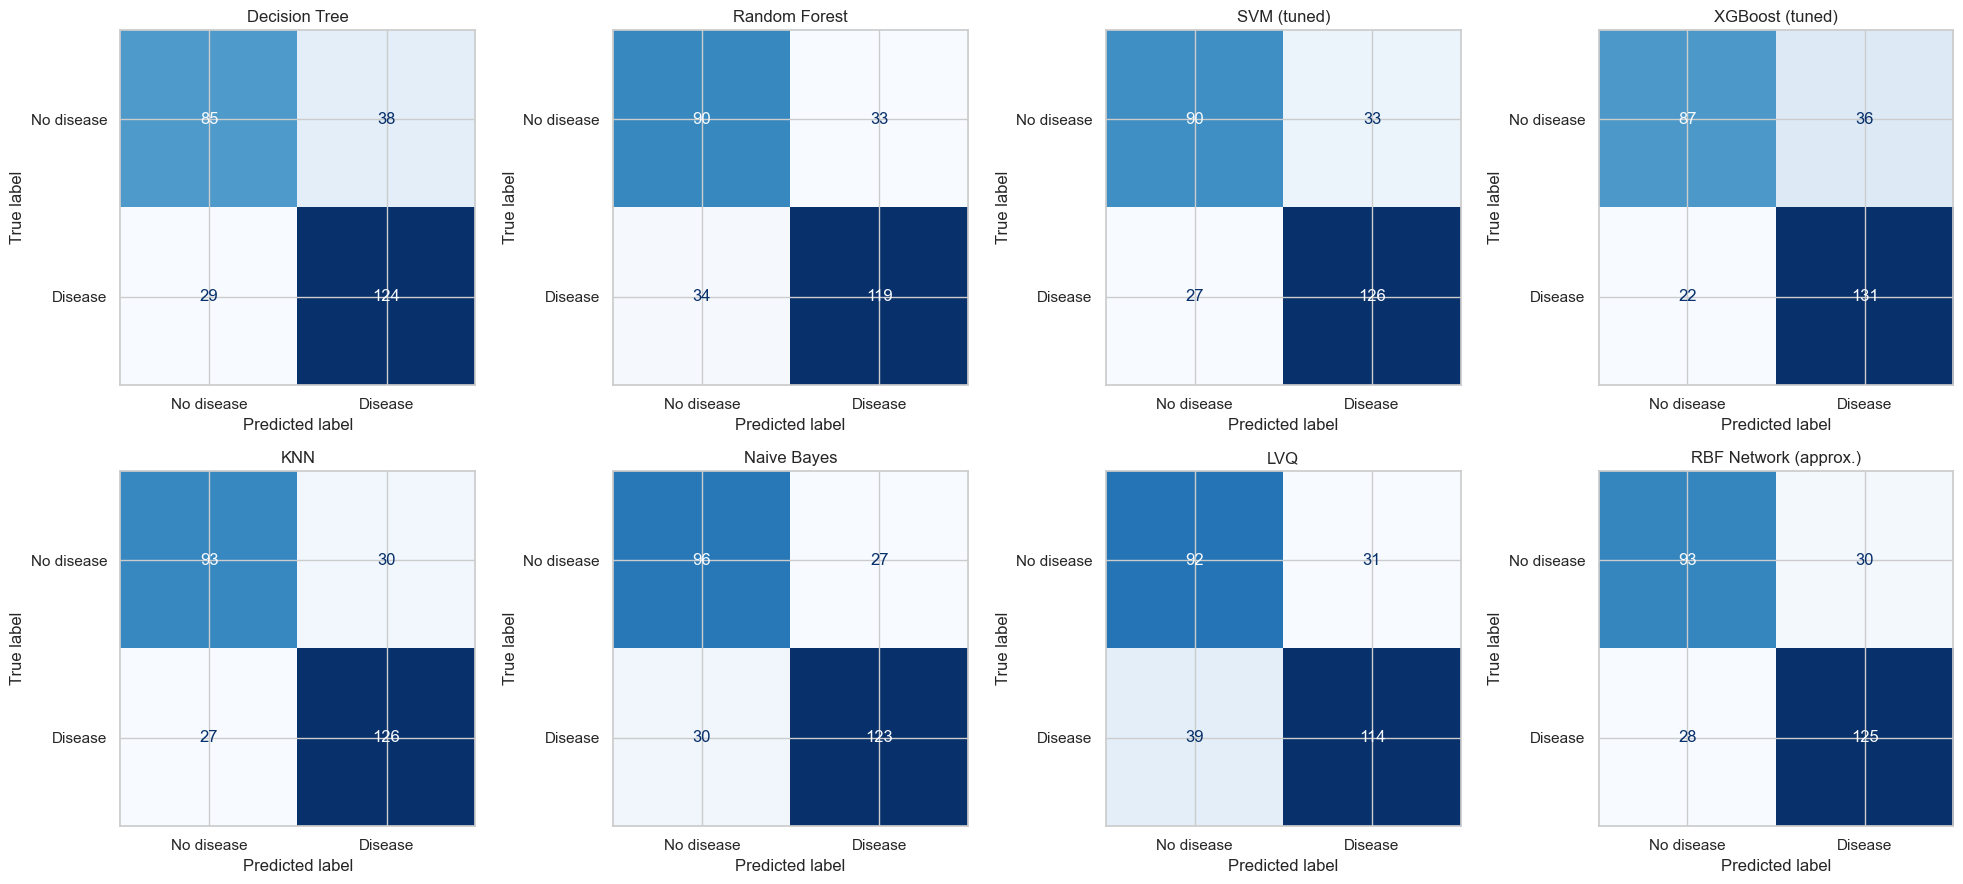

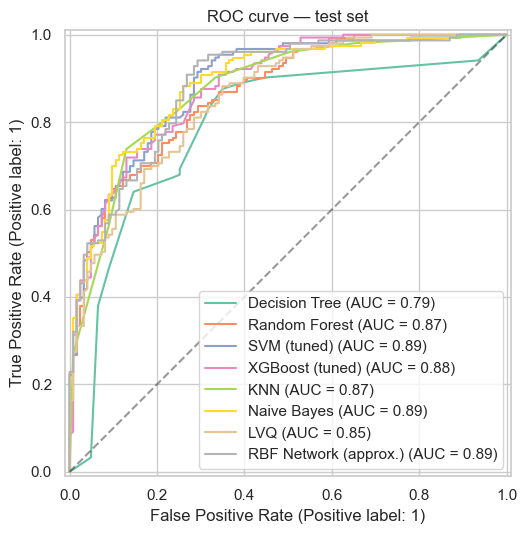

In [82]:
# ============================================================
# STEP 12: Evaluasi lengkap di test set (dilakukan SEKALI)
# ============================================================
def evaluate(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]
    return {
        "accuracy": accuracy_score(y_eval, pred),
        "balanced_acc": balanced_accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall (sensitivity)": recall_score(y_eval, pred),
        "specificity": recall_score(y_eval, pred, pos_label=0),
        "f1": f1_score(y_eval, pred),
        "roc_auc": roc_auc_score(y_eval, proba),
    }

results = pd.DataFrame(
    {name: evaluate(model, X_test, y_test) for name, model in final_models.items()}
).T

# skor CV di train pool sebagai pembanding terhadap skor test
results["cv_accuracy"] = pd.Series({
    name: search.best_score_ for name, search in all_searches.items()
})
print("\n=== HASIL TEST SET ===")
display(results.sort_values("roc_auc", ascending=False))

# Confusion matrix
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, name in zip(axes.flat, final_models.keys()):
    ConfusionMatrixDisplay.from_estimator(
        final_models[name], X_test, y_test,
        display_labels=["No disease", "Disease"], cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, model in final_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC curve — test set")
plt.tight_layout()
plt.show()

# Optional Checking

In [85]:
# ============================================================
# STEP 14: Optional Bootstrap CI (test set kecil -> estimasi punya ketidakpastian)
# + paired bootstrap untuk seluruh 8 model dibandingkan model terbaik
# ============================================================
def bootstrap_ci(y_true, y_hat, metric, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric(y_true[idx], y_hat[idx]))
    return np.percentile(scores, [2.5, 97.5])

preds = {n: final_models[n].predict(X_test) for n in final_models}
probas = {n: final_models[n].predict_proba(X_test)[:, 1] for n in final_models}

ci_rows = []
for name in preds:
    acc_lo, acc_hi = bootstrap_ci(y_test, preds[name], accuracy_score)
    auc_lo, auc_hi = bootstrap_ci(y_test, probas[name], roc_auc_score)
    ci_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds[name]),
        "acc_95CI": f"[{acc_lo:.3f}, {acc_hi:.3f}]",
        "roc_auc": roc_auc_score(y_test, probas[name]),
        "auc_95CI": f"[{auc_lo:.3f}, {auc_hi:.3f}]",
    })
ci_df = pd.DataFrame(ci_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
print("\n=== BOOTSTRAP 95% CI (test set) ===")
display(ci_df)

# ------------------------------------------------------------
# Paired bootstrap: setiap model dibandingkan terhadap model dengan
# akurasi test tertinggi (bukan cuma satu pasangan tetap seperti
# XGBoost vs SVM sebelumnya) — menjawab "apakah model terbaik memang
# signifikan lebih unggul dari model lain, atau masih dalam rentang noise?"
# ------------------------------------------------------------
def paired_bootstrap_diff(y_true, pred_a, pred_b, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_arr = np.asarray(y_true)
    correct_a = (pred_a == y_arr).astype(float)
    correct_b = (pred_b == y_arr).astype(float)
    n = len(y_arr)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs.append(correct_a[idx].mean() - correct_b[idx].mean())
    diffs = np.array(diffs)
    return correct_a.mean() - correct_b.mean(), np.percentile(diffs, [2.5, 97.5])

best_model_name = ci_df.iloc[0]["model"]
print(f"\n=== PAIRED BOOTSTRAP: seluruh model vs model terbaik ({best_model_name}) ===")

paired_rows = []
for name in final_models:
    if name == best_model_name:
        continue
    diff, (lo, hi) = paired_bootstrap_diff(y_test, preds[best_model_name], preds[name])
    paired_rows.append({
        "model_pembanding": name,
        f"selisih_akurasi_vs_{best_model_name}": diff,
        "95%_CI": f"[{lo:+.3f}, {hi:+.3f}]",
        "signifikan_beda?": "Ya" if lo > 0 or hi < 0 else "Tidak (CI mencakup 0)",
    })

paired_df = pd.DataFrame(paired_rows)
display(paired_df)
print("Kalau CI mencakup 0, perbedaan model tersebut dengan model terbaik tidak bisa dibedakan dari noise.")


=== BOOTSTRAP 95% CI (test set) ===


,model,accuracy,acc_95CI,roc_auc,auc_95CI
0,Naive Bayes,0.793,"[0.743, 0.841]",0.888,"[0.847, 0.928]"
1,KNN,0.793,"[0.743, 0.841]",0.875,"[0.831, 0.916]"
2,XGBoost (tuned),0.790,"[0.743, 0.841]",0.882,"[0.842, 0.922]"
3,RBF Network (approx.),0.790,"[0.743, 0.841]",0.885,"[0.844, 0.925]"
4,SVM (tuned),0.783,"[0.732, 0.833]",0.889,"[0.847, 0.929]"
5,Random Forest,0.757,"[0.706, 0.812]",0.866,"[0.822, 0.909]"
6,Decision Tree,0.757,"[0.707, 0.808]",0.792,"[0.736, 0.846]"
7,LVQ,0.746,"[0.692, 0.797]",0.855,"[0.806, 0.897]"



=== PAIRED BOOTSTRAP: seluruh model vs model terbaik (Naive Bayes) ===


,model_pembanding,selisih_akurasi_vs_Naive Bayes,95%_CI,signifikan_beda?
0,Decision Tree,0.036,"[-0.011, +0.083]",Tidak (CI mencakup 0)
1,Random Forest,0.036,"[-0.004, +0.076]",Tidak (CI mencakup 0)
2,SVM (tuned),0.011,"[-0.011, +0.036]",Tidak (CI mencakup 0)
3,XGBoost (tuned),0.004,"[-0.036, +0.043]",Tidak (CI mencakup 0)
4,KNN,0.000,"[-0.036, +0.040]",Tidak (CI mencakup 0)
5,LVQ,0.047,"[+0.011, +0.087]",Ya
6,RBF Network (approx.),0.004,"[-0.029, +0.033]",Tidak (CI mencakup 0)


Kalau CI mencakup 0, perbedaan model tersebut dengan model terbaik tidak bisa dibedakan dari noise.


In [86]:
# ============================================================
# STEP 16: Robustness antar sumber data (Cleveland/Hungarian/Switzerland/VA)
# Empat dataset digabung; distribusi tiap RS berbeda, jadi cek konsistensinya.
# ============================================================
# (a) Akurasi test set per sumber
source_test = df.loc[X_test.index, "source_file"].to_numpy()
y_test_arr = y_test.to_numpy()
rows = []
for name in preds:
    for src in sorted(np.unique(source_test)):
        m = source_test == src
        rows.append({
            "model": name, "source": src, "n_test": int(m.sum()),
            "positive_rate": y_test_arr[m].mean(),
            "accuracy": accuracy_score(y_test_arr[m], preds[name][m]),
        })
print("\n=== AKURASI TEST SET PER SUMBER ===")
display(pd.DataFrame(rows))

# (b) Leave-one-source-out di train pool (hyperparameter tetap = hasil GridSearch).
# Menjawab: "kalau dilatih di 3 sumber, apakah bisa generalisasi ke sumber ke-4?"
groups_pool = df.loc[X_train_pool.index, "source_file"]
group_order = sorted(groups_pool.unique())
loso_rows = []
for name, search in all_searches.items():
    res = cross_validate(
        clone(search.best_estimator_), X_train_pool, y_train_pool,
        groups=groups_pool, cv=LeaveOneGroupOut(),
        scoring=["accuracy", "roc_auc"], error_score=np.nan, n_jobs=1,
    )
    for grp, acc, auc in zip(group_order, res["test_accuracy"], res["test_roc_auc"]):
        loso_rows.append({"model": name, "held_out_source": grp, "accuracy": acc, "roc_auc": auc})
print("\n=== LEAVE-ONE-SOURCE-OUT (train pool) ===")
display(pd.DataFrame(loso_rows))


=== AKURASI TEST SET PER SUMBER ===


,model,source,n_test,positive_rate,accuracy
0,Decision Tree,processed.cleveland.data,90,0.489,0.700
1,Decision Tree,processed.hungarian.data,96,0.365,0.833
2,Decision Tree,processed.switzerland.data,39,0.949,0.795
3,Decision Tree,processed.va.data,51,0.725,0.686
4,Random Forest,processed.cleveland.data,90,0.489,0.722
5,Random Forest,processed.hungarian.data,96,0.365,0.760
6,Random Forest,processed.switzerland.data,39,0.949,0.872
7,Random Forest,processed.va.data,51,0.725,0.725
8,SVM (tuned),processed.cleveland.data,90,0.489,0.789
9,SVM (tuned),processed.hungarian.data,96,0.365,0.802


c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python31


=== LEAVE-ONE-SOURCE-OUT (train pool) ===


,model,held_out_source,accuracy,roc_auc
0,Decision Tree,processed.cleveland.data,0.662,0.644
1,Decision Tree,processed.hungarian.data,0.561,0.704
2,Decision Tree,processed.switzerland.data,0.643,0.718
3,Decision Tree,processed.va.data,0.738,0.641
4,Random Forest,processed.cleveland.data,0.728,0.825
5,Random Forest,processed.hungarian.data,0.763,0.833
6,Random Forest,processed.switzerland.data,0.726,0.801
7,Random Forest,processed.va.data,0.752,0.736
8,SVM (tuned),processed.cleveland.data,0.704,0.851
9,SVM (tuned),processed.hungarian.data,0.747,0.870
